# Deliverable 6d — 2.5D U-Net + Attention Gates (Attention U-Net)

**Single-variable change vs D6**: add learnable attention gates on each skip connection (Oktay et al., 2018).

### Why
Tumors are small, sparse structures. Standard U-Net skip connections pass *all* encoder features to the decoder, including features irrelevant for tumor localization. **Attention gates** learn to spatially re-weight skip features using the deeper decoder layer as a gating signal — letting the network say "tell me only about regions that look tumor-relevant given what I've seen so far."

### How it works
For each skip connection, an attention gate takes:
- **x**: encoder features (skip connection input)
- **g**: gating signal from the deeper decoder layer

It computes  ψ = σ(Wψ · ReLU(Wg·g + Wx·x))  and returns  **x ⊙ ψ**.

The gate is trained end-to-end. Adds 4 small attention modules totaling ~351K params (~1.1% over D6) — negligible compute cost.

## 1. Imports

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import DataLoader

from lits_core import (get_device, load_lits_paths, make_split,
                       LiTS25DDataset, UNet2D, train_model)

device = get_device()
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: mps
PyTorch: 2.11.0


## 2. Configuration

**Only change vs D6: `use_attention=True`** in the model. STACK_SIZE stays at 3, isolating the attention contribution.

In [2]:
DATA_DIR    = '/Users/aemanadnan/Desktop/DL proj/archive-2'
OUT_DIR     = './out_d6d'
TAG         = 'D6d'

IMG_SIZE    = 128
BATCH_SIZE  = 16
NUM_EPOCHS  = 15
LR          = 1e-4
SEED        = 42
STACK_SIZE  = 3       
USE_ATTENTION = True       

os.makedirs(OUT_DIR, exist_ok=True)
print(f'Use attention: {USE_ATTENTION}')

Use attention: True


## 3. Data Loading & Split (identical to D6)

In [3]:
volume_paths, seg_paths = load_lits_paths(DATA_DIR)
train_v, train_s, val_v, val_s, test_v, test_s = make_split(
    volume_paths, seg_paths, seed=SEED)

Found 51 matched volume-segmentation pairs
Split — Train: 35 | Val: 8 | Test: 8


## 4. Build Datasets (same as D6 — stack_size=3, no augmentation)

In [4]:
print('Building train dataset...')
train_dataset = LiTS25DDataset(train_v, train_s, img_size=IMG_SIZE,
                               stack_size=STACK_SIZE, augment=False)
print()
print('Building val dataset...')
val_dataset = LiTS25DDataset(val_v, val_s, img_size=IMG_SIZE,
                             stack_size=STACK_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Building train dataset...
Dataset: 4614 slices | stack=3 | augment=False (medium) | noise=None@0% (0 slices)

Building val dataset...
Dataset: 1116 slices | stack=3 | augment=False (medium) | noise=None@0% (0 slices)

Train batches: 289 | Val batches: 70


## 5. Build Model — `use_attention=True`

The Attention Gate module (defined in `lits_core.py`):
```python
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        ...
    def forward(self, g, x):
        g1  = self.W_g(g)              # gating signal projection
        x1  = self.W_x(x)              # skip features projection
        psi = self.psi(self.relu(g1 + x1))   # attention coefficients (0..1)
        return x * psi                 # spatially-gated skip features
```

The U-Net inserts one of these on **each of the 4 skip connections** — so the decoder gets attention-filtered features at every resolution level.

In [5]:
model = UNet2D(in_channels=STACK_SIZE, num_classes=3, base_features=64,
               use_attention=USE_ATTENTION).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

vanilla = UNet2D(in_channels=STACK_SIZE, num_classes=3, base_features=64,
                 use_attention=False)
n_vanilla = sum(p.numel() for p in vanilla.parameters() if p.requires_grad)

print(f'D6 (no attention) params:   {n_vanilla:>12,}')
print(f'D6d (with attention) params:{n_params:>12,}')
print(f'Attention overhead:         {n_params - n_vanilla:>+12,}  '
      f'({(n_params - n_vanilla)/n_vanilla*100:+.2f}%)')

del vanilla

D6 (no attention) params:     31,037,763
D6d (with attention) params:  31,388,331
Attention overhead:             +350,568  (+1.13%)


## 6. Train

In [6]:
history, best_state, best_tumor = train_model(
    model, train_loader, val_loader, device,
    num_epochs=NUM_EPOCHS, lr=LR, tag=TAG,
    save_path=os.path.join(OUT_DIR, 'best_unet_d6d.pth'),
    seed=SEED,
)

TRAINING: D6d
  Epochs=15 | LR=0.0001 | Device=mps | Params=31,388,331
  Train batches: 289 | Val batches: 70
  [D6d] Ep 01 batch 100/289 loss=0.8004
  [D6d] Ep 01 batch 200/289 loss=0.6632
[D6d] Ep 01/15 |  7.9min | Train: 0.7861 | Val: 0.6246 | Liver: 0.8704 | Tumor: 0.1662 *** BEST
  [D6d] Ep 02 batch 100/289 loss=0.5201
  [D6d] Ep 02 batch 200/289 loss=0.4310
[D6d] Ep 02/15 |  6.4min | Train: 0.4889 | Val: 0.5028 | Liver: 0.8726 | Tumor: 0.2698 *** BEST
  [D6d] Ep 03 batch 100/289 loss=0.3702
  [D6d] Ep 03 batch 200/289 loss=0.3380
[D6d] Ep 03/15 |  6.4min | Train: 0.3740 | Val: 0.4434 | Liver: 0.8829 | Tumor: 0.3074 *** BEST
  [D6d] Ep 04 batch 100/289 loss=0.2076
  [D6d] Ep 04 batch 200/289 loss=0.3014
[D6d] Ep 04/15 |  6.5min | Train: 0.2829 | Val: 0.4234 | Liver: 0.8766 | Tumor: 0.2826
  [D6d] Ep 05 batch 100/289 loss=0.2257
  [D6d] Ep 05 batch 200/289 loss=0.1445
[D6d] Ep 05/15 |  6.4min | Train: 0.1987 | Val: 0.4046 | Liver: 0.8777 | Tumor: 0.3267 *** BEST
  [D6d] Ep 06 batch

## 7. Results Summary

In [7]:
best_liver = float(np.max(history['val_liver_dice']))
best_ep    = int(np.argmax(history['val_tumor_dice']) + 1)

D3_LIVER, D3_TUMOR = 0.8885, 0.5011
D4_LIVER, D4_TUMOR = 0.8901, 0.4961
D5_LIVER, D5_TUMOR = 0.8886, 0.4774
D6_LIVER, D6_TUMOR = 0.8917, 0.5314

result = {
    'tag': TAG,
    'use_attention': USE_ATTENTION,
    'stack_size': STACK_SIZE,
    'best_tumor_dice': best_tumor,
    'best_liver_dice': best_liver,
    'best_epoch': best_ep,
    'history': history,
}
with open(os.path.join(OUT_DIR, 'results.json'), 'w') as f:
    json.dump(result, f, indent=2)

print('=' * 90)
print('D6d RESULTS — Attention U-Net (2.5D + Attention Gates)')
print('=' * 90)
print(f'{"":18}{"D3":>10}{"D4":>10}{"D5":>10}{"D6":>10}{"D6d":>10}{"vs D6":>10}{"vs D3":>10}')
print(f'{"Liver Dice":18}{D3_LIVER:>10.4f}{D4_LIVER:>10.4f}{D5_LIVER:>10.4f}{D6_LIVER:>10.4f}'
      f'{best_liver:>10.4f}{best_liver - D6_LIVER:>+10.4f}{best_liver - D3_LIVER:>+10.4f}')
print(f'{"Tumor Dice":18}{D3_TUMOR:>10.4f}{D4_TUMOR:>10.4f}{D5_TUMOR:>10.4f}{D6_TUMOR:>10.4f}'
      f'{best_tumor:>10.4f}{best_tumor - D6_TUMOR:>+10.4f}{best_tumor - D3_TUMOR:>+10.4f}')
print(f'{"Best epoch":18}{8:>10d}{7:>10d}{13:>10d}{8:>10d}{best_ep:>10d}')
print('=' * 90)

delta = best_tumor - D6_TUMOR
print()
if delta > 0.01:
    print(f'> Attention IMPROVED Tumor Dice by {delta:+.4f} over D6.')
    print('  The decoder learned to focus on tumor-relevant skip features.')
elif delta > -0.01:
    print(f'> Attention TIED D6 ({delta:+.4f}).')
    print('  Gates may be near-uniform — context already strong without them.')
else:
    print(f'> Attention HURT performance ({delta:+.4f}).')
    print('  Likely under-trained gates on this dataset size — would need more epochs or warm-start.')

D6d RESULTS — Attention U-Net (2.5D + Attention Gates)
                          D3        D4        D5        D6       D6d     vs D6     vs D3
Liver Dice            0.8885    0.8901    0.8886    0.8917    0.8954   +0.0037   +0.0069
Tumor Dice            0.5011    0.4961    0.4774    0.5314    0.5397   +0.0083   +0.0386
Best epoch                 8         7        13         8         7

> Attention TIED D6 (+0.0083).
  Gates may be near-uniform — context already strong without them.


## 8. Training Curves

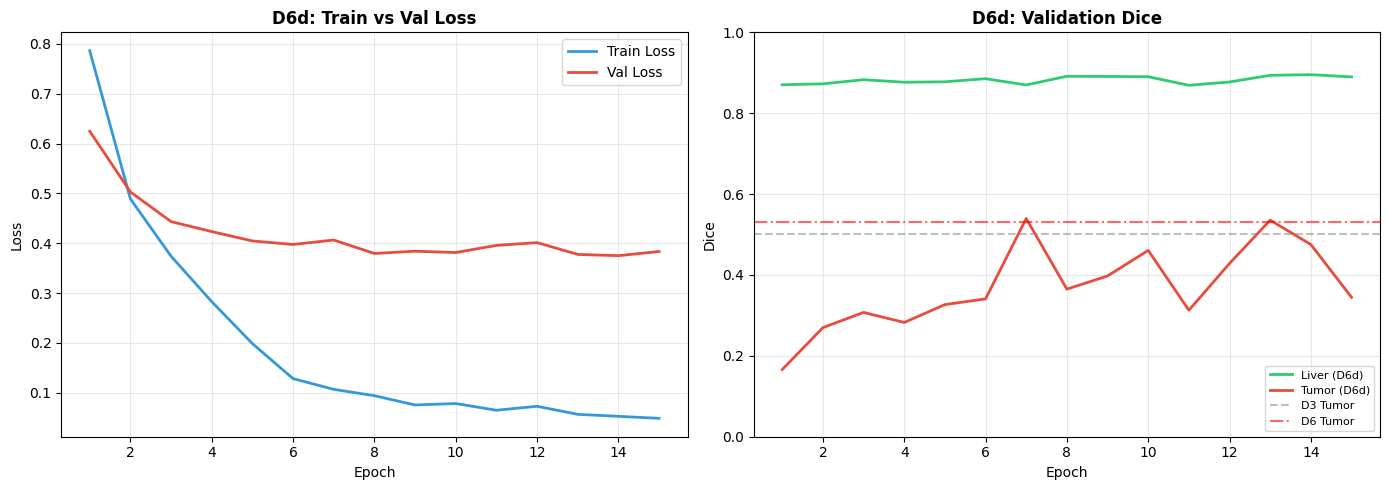

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, NUM_EPOCHS + 1)

axes[0].plot(ep, history['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(ep, history['val_loss'],   label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('D6d: Train vs Val Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_liver_dice'], label='Liver (D6d)', color='#2ecc71', linewidth=2)
axes[1].plot(ep, history['val_tumor_dice'], label='Tumor (D6d)', color='#e74c3c', linewidth=2)
axes[1].axhline(D3_TUMOR, ls='--', color='gray',  alpha=0.5, label='D3 Tumor')
axes[1].axhline(D6_TUMOR, ls='-.', color='red',   alpha=0.6, label='D6 Tumor')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice')
axes[1].set_ylim(0, 1)
axes[1].set_title('D6d: Validation Dice', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'training_curves_d6d.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Qualitative Predictions

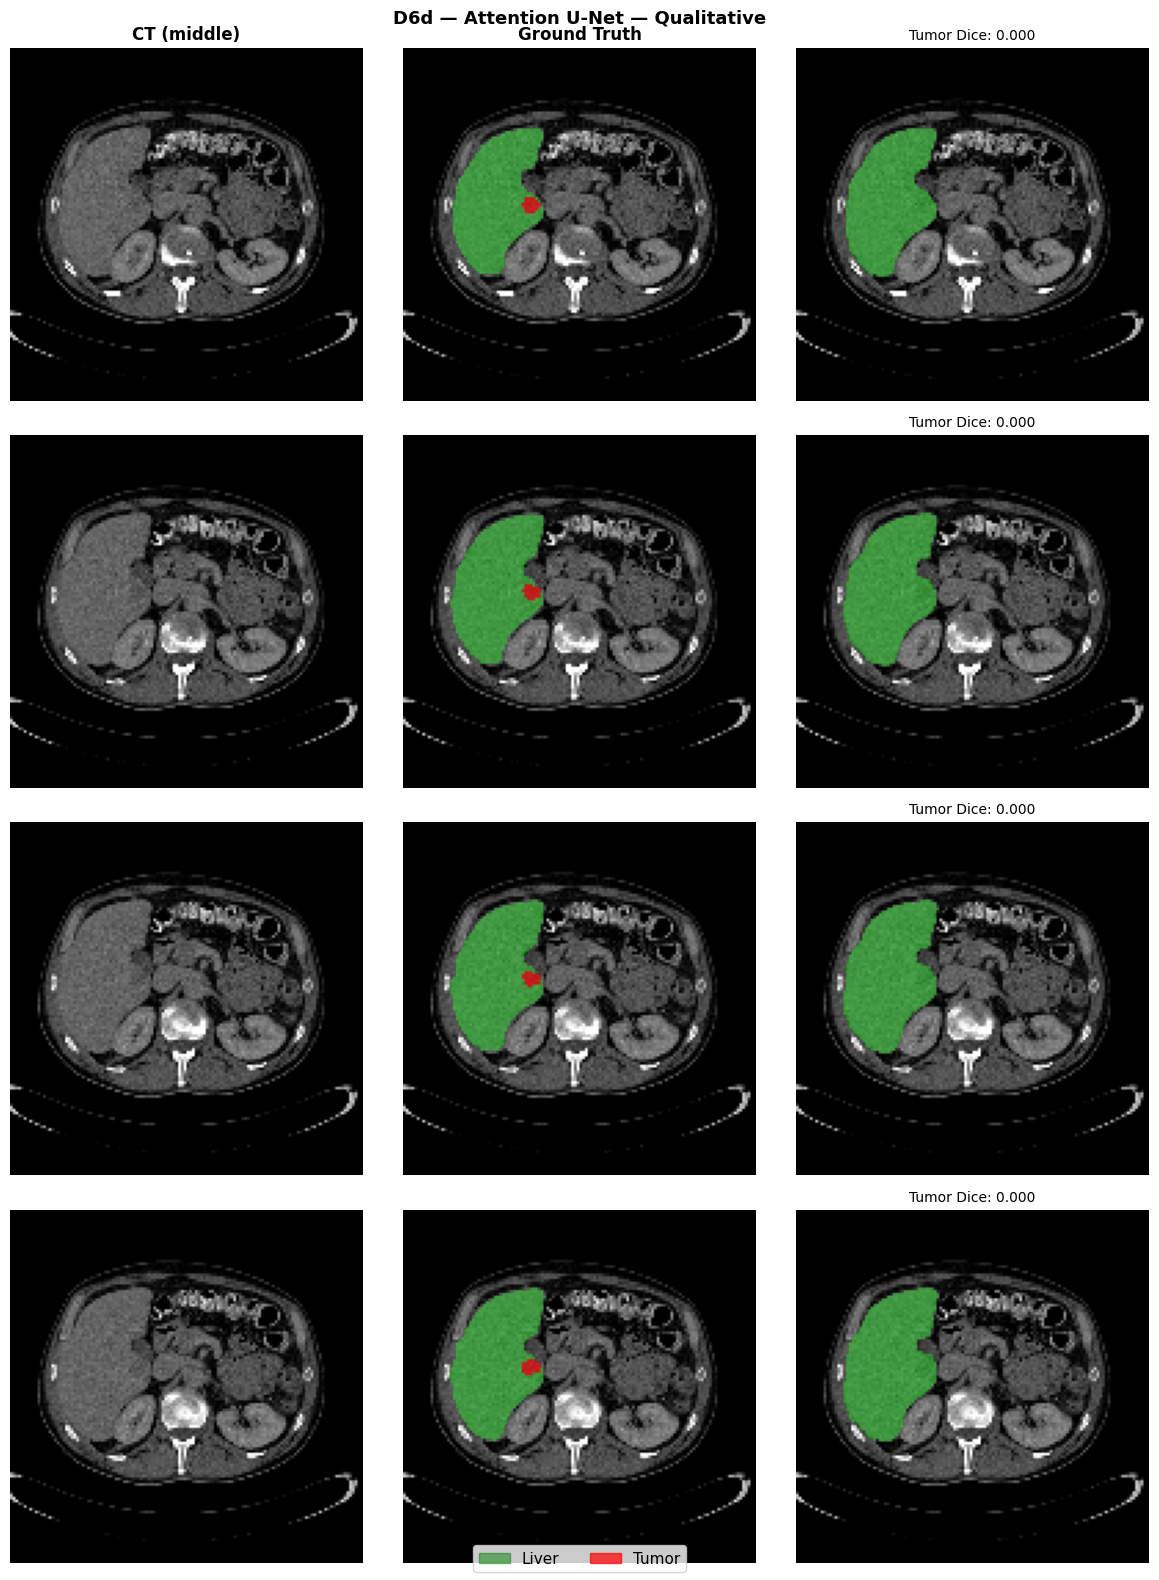

In [9]:
model.load_state_dict(best_state)
model.eval()

samples = []
with torch.no_grad():
    for ct_batch, seg_batch in val_loader:
        ct_batch = ct_batch.to(device); seg_batch = seg_batch.to(device)
        preds    = model(ct_batch)
        pred_cls = preds.argmax(dim=1)
        for i in range(ct_batch.shape[0]):
            gt = seg_batch[i].cpu().numpy()
            if (gt == 2).sum() > 30:
                mid = STACK_SIZE // 2
                samples.append({
                    'ct':   ct_batch[i, mid].cpu().numpy(),
                    'gt':   gt,
                    'pred': pred_cls[i].cpu().numpy(),
                })
        if len(samples) >= 4: break

def overlay(seg, ct):
    o = np.zeros((*ct.shape, 4))
    o[seg == 1] = [0, 1, 0, 0.35]
    o[seg == 2] = [1, 0, 0, 0.65]
    return o

n = min(4, len(samples))
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1: axes = [axes]
for col, t in enumerate(['CT (middle)', 'Ground Truth', 'Prediction']):
    axes[0][col].set_title(t, fontsize=12, fontweight='bold')
for row, s in enumerate(samples[:n]):
    ct, gt, pr = s['ct'], s['gt'], s['pred']
    axes[row][0].imshow(ct.T, cmap='gray', origin='lower'); axes[row][0].axis('off')
    axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][1].imshow(overlay(gt, ct).transpose(1,0,2), origin='lower'); axes[row][1].axis('off')
    axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][2].imshow(overlay(pr, ct).transpose(1,0,2), origin='lower')
    pt, gt_t = (pr == 2).astype(float), (gt == 2).astype(float)
    inter, denom = (pt * gt_t).sum(), pt.sum() + gt_t.sum()
    sd = (2 * inter / denom) if denom > 0 else 1.0
    axes[row][2].set_title(f'Tumor Dice: {sd:.3f}', fontsize=10); axes[row][2].axis('off')

g = mpatches.Patch(color='green', alpha=0.5, label='Liver')
r = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[g, r], loc='lower center', ncol=2, fontsize=11)
plt.suptitle('D6d — Attention U-Net — Qualitative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'qualitative_d6d.png'), dpi=150, bbox_inches='tight')
plt.show()

Total val slices with tumor (>30px): 184
  Mean per-slice tumor Dice : 0.1382
  Median per-slice tumor Dice: 0.0000
  % of slices with Dice > 0.3: 19.0%


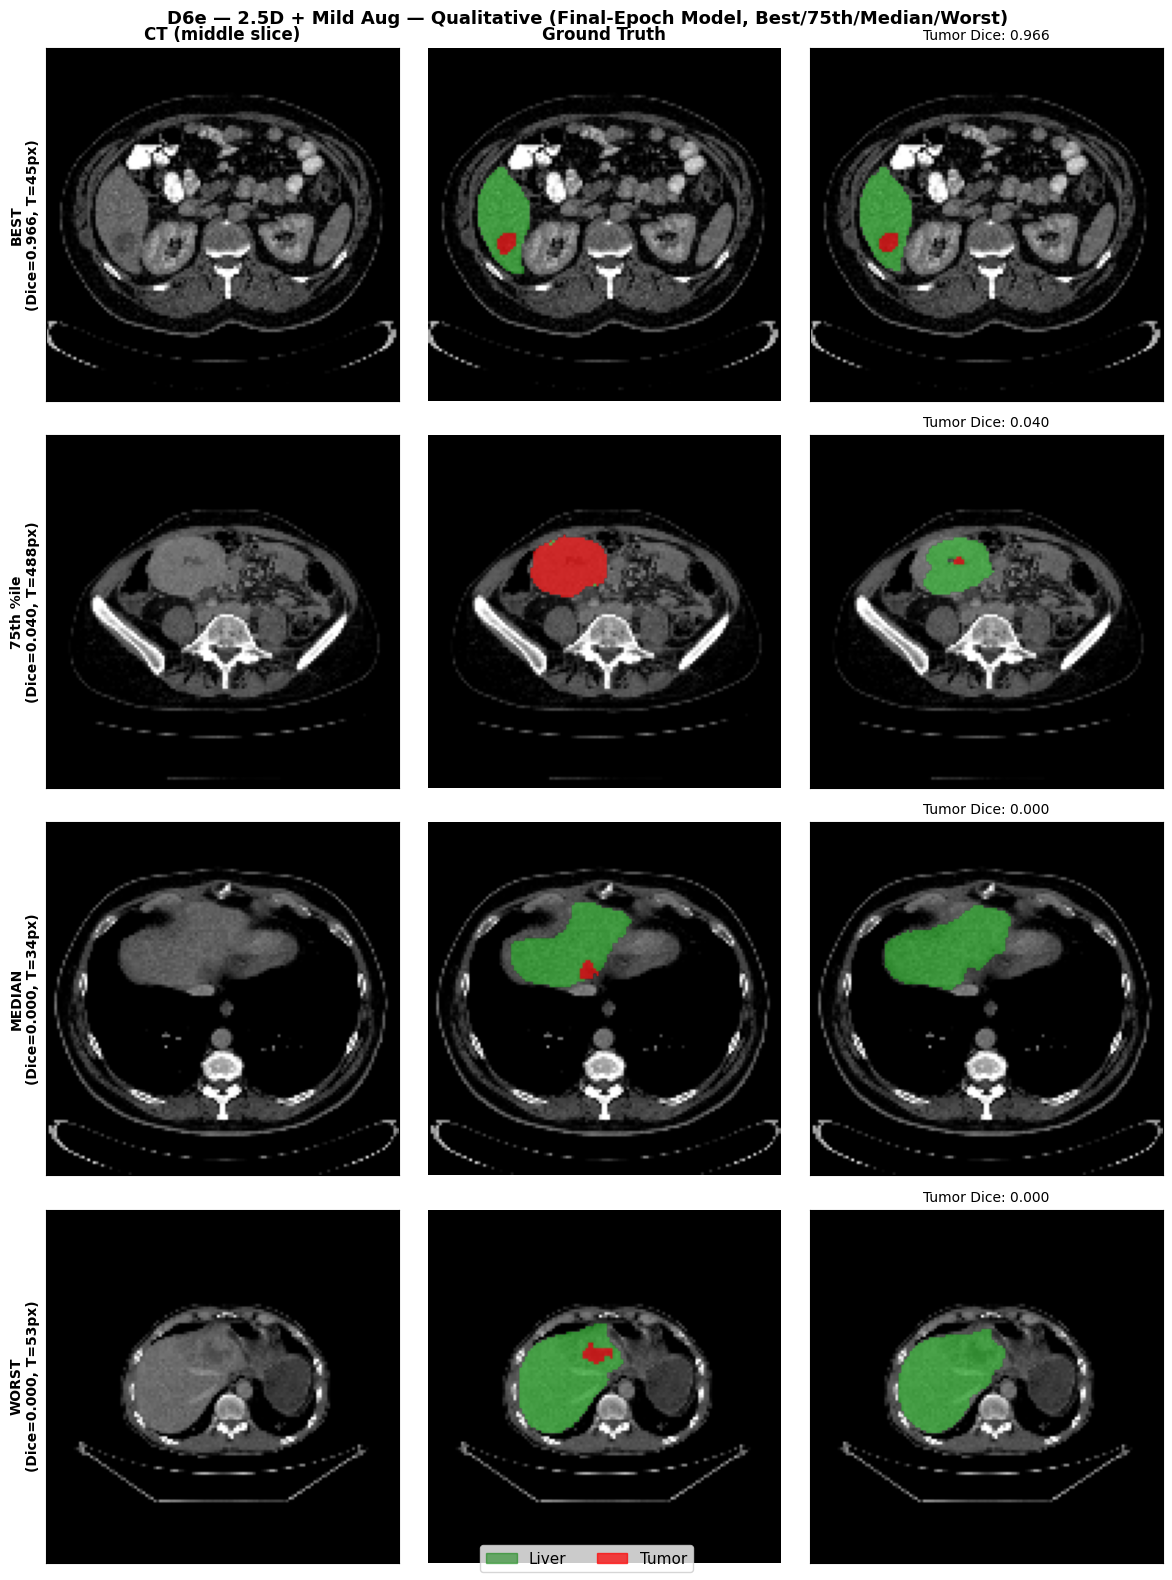

In [10]:
model.eval()

samples_all = []
with torch.no_grad():
    for ct_batch, seg_batch in val_loader:
        ct_batch = ct_batch.to(device); seg_batch = seg_batch.to(device)
        preds    = model(ct_batch)
        pred_cls = preds.argmax(dim=1)
        for i in range(ct_batch.shape[0]):
            gt = seg_batch[i].cpu().numpy()
            if (gt == 2).sum() < 30:
                continue
            pr = pred_cls[i].cpu().numpy()
            pt, gt_t = (pr == 2).astype(float), (gt == 2).astype(float)
            inter, denom = (pt * gt_t).sum(), pt.sum() + gt_t.sum()
            sd = (2 * inter / denom) if denom > 0 else 0.0
            mid = STACK_SIZE // 2
            samples_all.append({
                'ct':   ct_batch[i, mid].cpu().numpy(),
                'gt':   gt,
                'pred': pr,
                'dice': sd,
                'tumor_px': int((gt == 2).sum()),
            })

print(f'Total val slices with tumor (>30px): {len(samples_all)}')
if len(samples_all) > 0:
    dices = [s['dice'] for s in samples_all]
    print(f'  Mean per-slice tumor Dice : {np.mean(dices):.4f}')
    print(f'  Median per-slice tumor Dice: {np.median(dices):.4f}')
    print(f'  % of slices with Dice > 0.3: {np.mean([d > 0.3 for d in dices]) * 100:.1f}%')

samples_all.sort(key=lambda s: s['dice'], reverse=True)
n_total = len(samples_all)
if n_total >= 4:
    picks = [(0, 'BEST'),
             (n_total // 4, '75th %ile'),
             (n_total // 2, 'MEDIAN'),
             (n_total - 1, 'WORST')]
else:
    picks = [(i, f'#{i+1}') for i in range(n_total)]

samples = [samples_all[i] for i, _ in picks]
labels  = [lbl for _, lbl in picks]

def overlay(seg, ct):
    o = np.zeros((*ct.shape, 4))
    o[seg == 1] = [0, 1, 0, 0.35]
    o[seg == 2] = [1, 0, 0, 0.65]
    return o

n = len(samples)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1: axes = [axes]
for col, t in enumerate(['CT (middle slice)', 'Ground Truth', 'Prediction']):
    axes[0][col].set_title(t, fontsize=12, fontweight='bold')

for row, (s, lbl) in enumerate(zip(samples, labels)):
    ct, gt, pr, sd = s['ct'], s['gt'], s['pred'], s['dice']
    axes[row][0].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][0].set_ylabel(f'{lbl}\n(Dice={sd:.3f}, T={s["tumor_px"]}px)',
                            fontsize=10, fontweight='bold')
    axes[row][0].set_xticks([]); axes[row][0].set_yticks([])

    axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][1].imshow(overlay(gt, ct).transpose(1,0,2), origin='lower')
    axes[row][1].axis('off')

    axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][2].imshow(overlay(pr, ct).transpose(1,0,2), origin='lower')
    axes[row][2].set_title(f'Tumor Dice: {sd:.3f}', fontsize=10)
    axes[row][2].set_xticks([]); axes[row][2].set_yticks([])

g = mpatches.Patch(color='green', alpha=0.5, label='Liver')
r = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[g, r], loc='lower center', ncol=2, fontsize=11)
plt.suptitle(f'D6e — 2.5D + Mild Aug — Qualitative (Final-Epoch Model, Best/75th/Median/Worst)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'qualitative_d6e.png'), dpi=150, bbox_inches='tight')
plt.show()